# Case study: a social media content studio (multi-agent, human in the loop)

Notebooks 1-5 introduced the pieces one at a time. This one puts four of them into a single
production-shaped system:

| Piece | Where it came from |
|---|---|
| An agent with a web-search tool and structured output | `02`, `03` |
| Agents wrapped as subagents | `04` |
| Orchestrator-worker with `Send` fan-out | `05`, section 6 |
| Evaluator-optimizer feedback loop | `05`, section 7 |
| **Human-in-the-loop `interrupt()`** | new here |

**The brief.** Given a topic, produce a publishable social post about something that is *actually*
trending right now - and let a human choose the story before a single word is written.

**The pipeline.**

```
                    +-------------------------------------------------+
                    |                                                 |
START               |                                          revise + feedback
  |                 v                                                 |
  v          +--------------+                                         |
trend_scout  | content_     |   Send()   +----------------+           |
(agent 1     | planner      |----------->| section_writer |           |
 + web       | (agent 2 =   |----------->| (3 subagents,  |           |
 search)     | orchestrator)|----------->|  in parallel)  |           |
  |          +--------------+            +----------------+           |
  v                 ^                            |                    |
human_pick          |                            v                    |
(interrupt:         |                        assemble                 |
 human picks        |                            |                    |
 1 of 3 stories) ---+                            v                    |
                                             evaluator (agent 3) -----+
                                                 |
                                              publish -> END
```

Four agents, three of them subagents of the second, one human gate, one repair loop.

**Why a graph and not one big agent?** Because three of these steps are *not* the model's decision
to make. The human gate must happen, in that position, every time. The evaluator must run on every
draft. A `StateGraph` makes those guarantees; a prompt only asks for them (notebook 5, summary).

Prerequisites: notebooks `03`, `04`, `05`. Same versions: `langchain 1.4`, `langgraph 1.2`.

---
## 1. Setup

Two keys are needed: `OPENAI_API_KEY` and `TAVILY_API_KEY` (the trend scout is useless without a
live web search). `find_dotenv(usecwd=True)` walks up from this folder to the repo-root `.env`.

In [1]:
%pip install -q langchain langchain-openai langgraph tavily-python python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import os
import getpass
from datetime import date
from typing import Annotated, Literal

from dotenv import load_dotenv, find_dotenv
from langchain_openai import ChatOpenAI

load_dotenv(find_dotenv(usecwd=True))          # OPENAI_API_KEY, TAVILY_API_KEY


def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("OPENAI_API_KEY")
_set_env("TAVILY_API_KEY")

# gpt-4.1-mini: cheap enough to run this pipeline repeatedly, strong enough for tool calling
# and structured output. Every agent below shares one model - only the prompts differ.
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.4)

print("today is", date.today().strftime("%d %B %Y"))

today is 16 September 2026


---
## 2. The shared state

Everything the pipeline knows lives in one `TypedDict`. Read it top to bottom and you have the
whole data flow: the scout writes `candidates`, the human writes `chosen`, the planner writes
`plan`, the writers write `completed_sections`, `assemble` writes `draft`, the evaluator writes
`grade` and `feedback`.

One key needs a **reducer**. Three writers run in parallel and all append to `completed_sections`,
so plain assignment would have them overwrite each other (notebook 5, section 4). But
`operator.add` alone is not enough here: this graph *loops*. On a rewrite, the old three sections
are still sitting in the list and the new three would append to them, giving six.

So the reducer gets one extra rule - **`None` clears the slate**:

In [2]:
from typing_extensions import TypedDict
from pydantic import BaseModel, Field


def collect_sections(current: list, new: list | None) -> list:
    """Reducer for `completed_sections`.

    Workers append their one section. The planner sends `None` to wipe the previous
    draft's sections before a rewrite - without this, the revision loop accumulates.
    """
    if new is None:
        return []
    return current + new


# ---- what the scout returns -------------------------------------------------
class NewsItem(BaseModel):
    """One trending story, as a candidate to write about."""
    headline: str = Field(description="The story in under 14 words.")
    summary: str = Field(description="Two or three sentences of what actually happened.")
    why_trending: str = Field(description="Why this is getting attention *this week*.")
    url: str = Field(description="Source URL, copied from the search results. Never invented.")


class TrendingNews(BaseModel):
    """The scout's shortlist."""
    items: list[NewsItem] = Field(description="Exactly three stories, most newsworthy first.")


# ---- what the planner returns -----------------------------------------------
class Section(BaseModel):
    """A brief for one section of the post - not the text itself."""
    kind: Literal["hook", "main", "closing"]
    goal: str = Field(description="What this section must achieve, in one sentence.")
    must_include: str = Field(description="Concrete detail from the news this section must carry.")
    word_budget: int = Field(description="Target length in words.")


class ContentPlan(BaseModel):
    """The planner's output: an angle plus one brief per section."""
    angle: str = Field(description="The single argument the whole post makes.")
    sections: list[Section] = Field(description="Exactly three: one hook, one main, one closing.")


# ---- what the evaluator returns ---------------------------------------------
class Verdict(BaseModel):
    """The evaluator's judgement on a finished draft."""
    grade: Literal["publish", "revise"]
    hook_score: int = Field(description="1-5. Does it stop the scroll in the first line?")
    main_score: int = Field(description="1-5. Concrete, accurate, on-angle?")
    closing_score: int = Field(description="1-5. Lands the point, gives a reason to engage?")
    feedback: str = Field(
        description="Empty if publish. Otherwise specific, actionable fixes, labelled by section."
    )


# ---- graph state ------------------------------------------------------------
class State(TypedDict):
    topic: str                                              # the input
    candidates: list[dict]                                  # agent 1: shortlist of 3
    chosen: dict                                            # the human: 1 of the 3
    angle: str                                              # agent 2
    plan: list[dict]                                        # agent 2: 3 section briefs
    completed_sections: Annotated[list, collect_sections]    # the 3 subagents, in parallel
    draft: str                                              # assembled post
    grade: str                                              # agent 3
    scores: dict
    feedback: str                                           # the repair instruction
    revision: int


class WriterState(TypedDict):
    """The private state of one section writer. It sees its own brief and nothing else."""
    topic: str
    chosen: dict
    section: dict
    feedback: str
    completed_sections: Annotated[list, collect_sections]


print("state keys:", list(State.__annotations__))

state keys: ['topic', 'candidates', 'chosen', 'angle', 'plan', 'completed_sections', 'draft', 'grade', 'scores', 'feedback', 'revision']


---
## 3. Agent 1 - the trend scout

A normal `create_agent` (notebook 3) with one tool and `response_format=TrendingNews`. Two details
matter:

- **Today's date goes in the prompt.** The model's training data has a cutoff; without the date it
  happily calls last year's news "trending". This is the single most common bug in
  "find what's trending" agents.
- **`url` is a field in the schema.** Structured output is where you enforce citations. The prompt
  says copy them from search results; the schema makes leaving them out impossible.

In [3]:
from langchain.tools import tool
from langchain.agents import create_agent
from tavily import TavilyClient

tavily = TavilyClient(os.environ["TAVILY_API_KEY"])


@tool
def web_search(query: str) -> str:
    """Search the live web for news, announcements and current discussion.

    Use for anything that happened recently. Returns titles, snippets, dates and URLs.
    """
    hits = tavily.search(query, max_results=6, topic="news", days=14)["results"]
    return "\n\n".join(
        f"{h['title']}\n{h.get('published_date', 'no date')}\n{h['content']}\n{h['url']}"
        for h in hits
    )


SCOUT_SYSTEM = """You are a social media trend scout. You find what people are talking about
RIGHT NOW - not what is generally true about a topic.

Method:
1. Search at least twice with different phrasings. One broad, one narrow.
2. Prefer stories from the last 14 days. Reject anything you cannot date.
3. Return the three most newsworthy, and rank them: most newsworthy first.

Rules:
- Every URL must be copied from a search result. Never construct or guess one.
- Three distinct stories. Not three articles about the same announcement.
- No opinions, no marketing language. Report what happened."""

trend_scout_agent = create_agent(
    model=llm,
    tools=[web_search],
    system_prompt=SCOUT_SYSTEM,
    response_format=TrendingNews,
)


def trend_scout(state: State):
    """Agent 1: search the web, return a shortlist of three trending stories."""
    result = trend_scout_agent.invoke({"messages": [{"role": "user", "content":
        f"Topic: {state['topic']}\n"
        f"Today's date: {date.today().strftime('%d %B %Y')}.\n"
        f"Find the top 3 trending stories on this topic."}]})

    news: TrendingNews = result["structured_response"]
    # .model_dump(): graph state is checkpointed as JSON, so store dicts, not Pydantic objects.
    return {"candidates": [item.model_dump() for item in news.items[:3]]}


print("scout tool:", web_search.name)

scout tool: web_search


### 3a. Run the scout on its own first

Always test a node in isolation before wiring it into a graph. If the URLs are wrong or the stories
are stale, no amount of downstream engineering saves the post.

In [ ]:
TOPIC = "Latest news in the Agentic AI & LLM worlds"

probe = trend_scout({"topic": TOPIC})
for i, c in enumerate(probe["candidates"], 1):
    print(f"{i}. {c['headline']}")
    print(f"   why now : {c['why_trending']}")
    print(f"   source  : {c['url']}\n")

1. Factory raises $200M for its self-improving AI software development platform
   why now : This funding announcement highlights significant investor confidence and adoption of AI coding agents that autonomously improve software development workflows in 2026.
   source  : https://siliconangle.com/2026/09/15/factory-raises-200m-for-its-self-improving-software-development-platform/

2. Microsoft engineer declares 'typing code is absolutely over' with GitHub Copilot advances
   why now : This statement from a Microsoft engineer and new Copilot capabilities signal a major shift in developer workflows toward AI-driven coding agents this week.
   source  : https://www.techspot.com/news/113752-microsoft-engineer-typing-code-absolutely-over-github-copilot.html

3. AI agent startups raise billions to build autonomous software developers in 2026
   why now : Recent massive funding rounds and new startups spotlight the rapid growth and ambition in AI coding agents as autonomous software develope

---
## 4. The human gate - `interrupt()`

This is the new primitive. `interrupt(payload)` **stops the graph mid-node**, checkpoints
everything, and returns the payload to whoever called `invoke`. Nothing runs until you resume.

```python
choice = interrupt({...})   # execution stops HERE
```

When you resume with `Command(resume=value)`, the node **runs again from the top**, and this time
`interrupt(...)` returns `value` instead of pausing. Two consequences worth internalising:

1. **Everything before the `interrupt` call in that node runs twice.** Keep the node trivial - no
   API calls, no writes, no side effects above the interrupt.
2. **It needs a checkpointer and a `thread_id`.** The pause is persisted state; that is what makes
   the human's answer arrive minutes or days later, in a different process, in a web UI.

Why put the gate *here*, between scout and planner? Because this is the one decision that is
expensive to get wrong and cheap to ask about. Choosing the story is editorial judgement, and it
costs the human five seconds. Everything after it is craft, and the agents do it well.

In [5]:
from langgraph.types import interrupt, Send, Command


def human_pick(state: State):
    """The human in the loop: choose which of the three stories to write about."""
    options = [
        {"choice": i, "headline": c["headline"], "why_trending": c["why_trending"], "url": c["url"]}
        for i, c in enumerate(state["candidates"], 1)
    ]

    # Execution stops here and the payload is handed to the caller.
    answer = interrupt({
        "question": f"Which trending story should the post be about? (topic: {state['topic']})",
        "options": options,
        "how_to_answer": "Resume with 1, 2 or 3 - or with any part of the headline.",
    })

    # From here down, `answer` is whatever came back in Command(resume=...).
    picked = _resolve_choice(answer, state["candidates"])

    return {"chosen": picked, "revision": 0, "feedback": ""}


def _resolve_choice(answer, candidates: list[dict]) -> dict:
    """Accept 1/2/3, "2", or a headline fragment. Be forgiving: humans type things."""
    if isinstance(answer, int):
        return candidates[max(1, min(answer, len(candidates))) - 1]

    text = str(answer).strip()
    if text.isdigit():
        return candidates[max(1, min(int(text), len(candidates))) - 1]

    for c in candidates:
        if text.lower() in c["headline"].lower():
            return c

    raise ValueError(f"Could not match {answer!r} to any of the three headlines.")


print("human_pick ready - it pauses the graph, it does not call a model")

human_pick ready - it pauses the graph, it does not call a model


---
## 5. Agent 2 - the planner, and its three subagent writers

Agent 2 is an **orchestrator** (notebook 5, section 6). Its job description is deliberately narrow:

> Decide the angle. Write three section briefs. Write no prose.

The prose comes from three subagents, one per section, fanned out with `Send`. The planner never
writes a word itself - and that constraint is what makes the system better than one writer agent:

- A **hook** writer optimises for one thing (stop the scroll) and can be prompted hard for it.
- A **main** writer needs facts, so it gets `web_search`. The other two do not, so they don't get it.
- A **closing** writer needs the *point*, not the whole draft, so it stays short and doesn't ramble.

Three sharp prompts beat one prompt asking for three different voices.

In [6]:
from langchain.messages import SystemMessage, HumanMessage

planner_llm = llm.with_structured_output(ContentPlan)

PLANNER_SYSTEM = """You are the content lead for a social media studio. You plan posts; you never
write them. Junior writers execute your briefs literally, so the briefs must be specific.

Every post has exactly three sections:
- hook    : 1-2 lines. Earns the click. Concrete, never a rhetorical question, never "In today's
            fast-paced world".
- main    : the substance. What happened, why it matters, one concrete detail or number.
- closing : lands the angle and gives the reader a reason to reply.

Pick ONE angle and make all three sections serve it. In `must_include`, name the actual detail from
the story the writer has to use - do not write "mention the details"."""


def content_planner(state: State):
    """Agent 2: turn the chosen story into an angle plus three section briefs."""
    news = state["chosen"]
    brief = (
        f"Topic: {state['topic']}\n\n"
        f"Story to write about:\n"
        f"  headline : {news['headline']}\n"
        f"  summary  : {news['summary']}\n"
        f"  why now  : {news['why_trending']}\n"
        f"  source   : {news['url']}\n\n"
        f"Plan a short post (about 150 words total) for LinkedIn/X."
    )

    # On a rewrite, the evaluator's feedback becomes part of the brief.
    if state.get("feedback"):
        brief += (
            f"\n\nThis is REVISION {state['revision']}. The previous draft was rejected.\n"
            f"Editor's feedback:\n{state['feedback']}\n\n"
            f"Re-plan to fix exactly these problems. Keep what was not criticised."
        )

    plan: ContentPlan = planner_llm.invoke(
        [SystemMessage(content=PLANNER_SYSTEM), HumanMessage(content=brief)]
    )

    order = {"hook": 0, "main": 1, "closing": 2}
    sections = sorted((s.model_dump() for s in plan.sections), key=lambda s: order[s["kind"]])

    return {
        "angle": plan.angle,
        "plan": sections,
        "completed_sections": None,   # <- the reducer reads None as "clear the previous draft"
    }

In [7]:
# --- the three subagents ------------------------------------------------------
hook_writer = create_agent(
    model=llm,
    tools=[],
    system_prompt=(
        "You write social media hooks and nothing else. One or two lines, under 25 words. "
        "Start with the concrete thing that happened - a name, a number, a change. "
        "Banned: rhetorical questions, 'In today's world', 'Let's dive in', emoji, hashtags. "
        "Return the hook text only. No labels, no quotes, no commentary."
    ),
)

main_writer = create_agent(
    model=llm,
    tools=[web_search],
    system_prompt=(
        "You write the body of short social posts for a professional audience. Plain sentences, "
        "no hype, no hashtags. Say what happened, then why it matters to the reader's work. "
        "You may run web_search ONCE to confirm a detail or find one supporting number - but "
        "never contradict the story you were given, and never invent figures. "
        "Return the body text only. No labels, no commentary."
    ),
)

closing_writer = create_agent(
    model=llm,
    tools=[],
    system_prompt=(
        "You write closing lines for social posts. Two lines maximum. Land the angle in a "
        "statement, then invite a reply with a specific question about the reader's own "
        "experience. No 'What do you think?', no 'Thoughts?', no hashtags. "
        "Return the closing text only."
    ),
)

WRITERS = {"hook": hook_writer, "main": main_writer, "closing": closing_writer}


def section_writer(state: WriterState):
    """One worker = one section = one subagent. Runs three times in parallel."""
    section = state["section"]
    news = state["chosen"]
    agent = WRITERS[section["kind"]]

    task = (
        f"Post topic: {state['topic']}\n\n"
        f"Story:\n  {news['headline']}\n  {news['summary']}\n  source: {news['url']}\n\n"
        f"Your section  : {section['kind']}\n"
        f"Goal          : {section['goal']}\n"
        f"Must include  : {section['must_include']}\n"
        f"Word budget   : about {section['word_budget']} words"
    )
    if state.get("feedback"):
        task += f"\n\nThe editor rejected the last version. Fix this:\n{state['feedback']}"

    result = agent.invoke({"messages": [{"role": "user", "content": task}]})

    # Return only the final answer - the subagent's search results and reasoning stay behind
    # (notebook 4). The parent graph's state never sees them.
    return {"completed_sections": [{
        "kind": section["kind"],
        "text": result["messages"][-1].content.strip(),
    }]}


def assign_writers(state: State):
    """Conditional edge: one Send per section brief, dispatched in parallel."""
    return [
        Send("section_writer", {
            "topic": state["topic"],
            "chosen": state["chosen"],
            "section": section,
            "feedback": state.get("feedback", ""),
        })
        for section in state["plan"]
    ]


SECTION_ORDER = {"hook": 0, "main": 1, "closing": 2}


def assemble(state: State):
    """Join the three sections into a post.

    Parallel workers finish in whatever order they finish, so sort by `kind` - never rely on
    the order things landed in a reducer list.
    """
    parts = sorted(state["completed_sections"], key=lambda s: SECTION_ORDER[s["kind"]])
    return {"draft": "\n\n".join(p["text"] for p in parts)}


print("subagents:", list(WRITERS))

subagents: ['hook', 'main', 'closing']


---
## 6. Agent 3 - the evaluator, and the repair loop

The evaluator-optimizer pattern from notebook 5, section 7, with one change: the thing being
repaired is a **whole subsystem**, not a single LLM call. A `revise` verdict sends the feedback back
to the planner, which re-plans and re-dispatches all three writers.

Three rules make this loop safe:

1. **The evaluator never rewrites.** It grades and it names fixes. The moment an evaluator is
   allowed to edit, you lose the independent check and the loop silently becomes one agent talking
   to itself.
2. **`MAX_REVISIONS` is a hard stop.** An evaluator with a strict rubric and no counter will loop
   forever - it is *always* possible to want one more improvement. Two attempts, then ship the best
   draft you have.
3. **State the rubric as requirements, not failure conditions.** This one is learned the hard way.
   An earlier version of this prompt listed what makes a draft *fail* - "the hook names nothing
   specific" - and the model inverted it: it told the writers to *strip out* the company name and
   the numbers, then failed the next draft for having no concrete detail. Two rewrites later the
   post was worse than the first draft. A rubric phrased as *"the hook names something concrete"*,
   plus one explicit guard rail (*never ask the writer to remove a name, number or date*), does not
   have that failure mode. In a repair loop, an ambiguous rubric does not just misgrade - it
   actively damages the work.

In [8]:
evaluator_llm = llm.with_structured_output(Verdict)

EVALUATOR_SYSTEM = """You are a demanding social media editor. You grade drafts; you never rewrite
them.

A publishable draft meets all five requirements:
1. SPECIFIC HOOK. The hook names something concrete from the story - a company, product, number or
   date. A hook that could open a post about any other story does not meet this.
2. CONCRETE BODY. The body carries at least one detail, number, name or date from the source story.
3. ON ANGLE. Every section serves the stated angle.
4. CLEAN LANGUAGE. No hype words ("revolutionary", "game-changing"), no hashtags, no lazy call to
   action ("Thoughts?", "What do you think?", "Agree?"). A closing question about the reader's own
   work is fine and is NOT a lazy call to action.
5. COHERENT CLOSING. The closing follows from the body.

Grade `publish` if all five are met. Grade `revise` if any is unmet. Judge against these five only:
do not withhold `publish` because you can imagine a better post. The scores are for the record;
the grade follows the requirements.

Feedback rules, when the grade is `revise`: name the section, name the unmet requirement, and say
how to MEET it - e.g. "hook (1): replace 'AI is changing everything' with the model name and the
benchmark number". Never ask the writer to remove a name, number, date or concrete detail: those
are required, and a draft is never rejected for having them. Never rewrite the post yourself.
Never give feedback when the grade is publish."""

MAX_REVISIONS = 2


def evaluator(state: State):
    """Agent 3: grade the assembled draft, or send it back with instructions."""
    news = state["chosen"]
    verdict: Verdict = evaluator_llm.invoke([
        SystemMessage(content=EVALUATOR_SYSTEM),
        HumanMessage(content=(
            f"Intended angle: {state['angle']}\n\n"
            f"Source story:\n  {news['headline']}\n  {news['summary']}\n\n"
            f"Draft:\n{state['draft']}"
        )),
    ])

    return {
        "grade": verdict.grade,
        "feedback": verdict.feedback if verdict.grade == "revise" else "",
        "scores": {
            "hook": verdict.hook_score,
            "main": verdict.main_score,
            "closing": verdict.closing_score,
        },
        # Count only rejections - a `publish` on the first pass leaves this at 0.
        "revision": state.get("revision", 0) + (1 if verdict.grade == "revise" else 0),
    }


def route_after_review(state: State):
    """Conditional edge: publish, or send the feedback back to the planner."""
    if state["grade"] == "publish":
        return "Publish"
    if state["revision"] > MAX_REVISIONS:
        print(f"[evaluator] still unhappy after {MAX_REVISIONS} rewrites - shipping anyway")
        return "Publish"
    return "Revise + feedback"

---
## 7. Wire it up

Nine lines of graph. Note the two conditional edges - one fans out with `Send`, one loops back -
and `checkpointer=InMemorySaver()`, without which `interrupt()` raises.

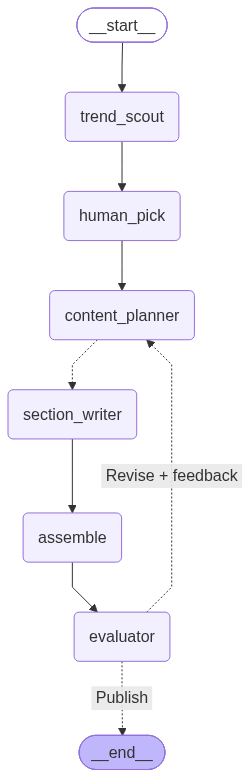

In [9]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image, display, Markdown

builder = StateGraph(State)

builder.add_node("trend_scout", trend_scout)
builder.add_node("human_pick", human_pick)
builder.add_node("content_planner", content_planner)
builder.add_node("section_writer", section_writer)
builder.add_node("assemble", assemble)
builder.add_node("evaluator", evaluator)

builder.add_edge(START, "trend_scout")
builder.add_edge("trend_scout", "human_pick")
builder.add_edge("human_pick", "content_planner")
builder.add_conditional_edges("content_planner", assign_writers, ["section_writer"])
builder.add_edge("section_writer", "assemble")
builder.add_edge("assemble", "evaluator")
builder.add_conditional_edges(
    "evaluator",
    route_after_review,
    {
        "Publish": END,
        "Revise + feedback": "content_planner",   # the repair loop
    },
)

# The checkpointer is not optional here: interrupt() persists the pause, and the thread_id is
# how the resume finds it again.
studio = builder.compile(checkpointer=InMemorySaver())

display(Image(studio.get_graph().draw_mermaid_png()))

---
## 8. Run it - phase 1, up to the human gate

`invoke` returns as soon as the graph pauses. The result is not a finished post; it is a **question**,
under the `__interrupt__` key.

In [10]:
thread = {"configurable": {"thread_id": "studio-run-1"}}

paused = studio.invoke({"topic": TOPIC}, thread)

ask = paused["__interrupt__"][0].value
print(ask["question"], "\n")
for opt in ask["options"]:
    print(f"[{opt['choice']}] {opt['headline']}")
    print(f"    why now: {opt['why_trending']}")
    print(f"    source : {opt['url']}\n")
print(ask["how_to_answer"])
print("\nnext node:", studio.get_state(thread).next)

Which trending story should the post be about? (topic: AI coding agents for software developers) 

[1] Microsoft Engineer Declares 'Typing Code is Absolutely Over' with GitHub Copilot's New AI Agent
    why now: This week, the announcement that AI coding agents are taking over core coding tasks has sparked major discussion about the future role of developers and the evolution of software engineering workflows.
    source : https://www.techspot.com/news/113752-microsoft-engineer-typing-code-absolutely-over-github-copilot.html

[2] Factory Raises $200M to Expand Its Self-Improving AI Software Development Platform
    why now: The large funding round and the platform's growing adoption highlight the rapid advancement and commercialization of AI coding agents in real-world software projects as of mid-September 2026.
    source : https://siliconangle.com/2026/09/15/factory-raises-200m-for-its-self-improving-software-development-platform/

[3] AI Agent Startups Raise Billions to Build Autono

### 8a. The human answers

`Command(resume=...)` restarts `human_pick`, and this time `interrupt()` returns the value instead
of pausing. In a real product this is an HTTP request landing on the same `thread_id` - possibly
hours later, from a phone.

Change `CHOICE` and re-run from here to write a post about a different story. Streaming with
`stream_mode="updates"` shows each node firing, including the three parallel writers.

In [12]:
#CHOICE = 1        # <- the human in the loop. Try 2 or 3, or "1" / a headline fragment.
CHOICE = input("Pick a story (1/2/3): ")     # uncomment for a real prompt

for chunk in studio.stream(Command(resume=CHOICE), thread, stream_mode="updates"):
    for node, update in chunk.items():
        if node == "human_pick":
            print(f"[{node:16s}] human chose: {update['chosen']['headline']}")
        elif node == "content_planner":
            print(f"[{node:16s}] angle: {update['angle']}")
            for s in update["plan"]:
                print(f"{'':18s}  - {s['kind']:8s} ~{s['word_budget']:>3d}w  {s['goal']}")
        elif node == "section_writer":
            written = update["completed_sections"][0]
            print(f"[{node:16s}] {written['kind']:8s} {len(written['text'].split()):>3d} words")
        elif node == "assemble":
            print(f"[{node:16s}] draft assembled ({len(update['draft'].split())} words)")
        elif node == "evaluator":
            print(f"[{node:16s}] {update['grade'].upper()}  scores={update['scores']}")
            if update["feedback"]:
                print(f"{'':18s}  feedback: {update['feedback']}")

### 8b. The finished post

In [13]:
final = studio.get_state(thread).values

verdict = final["grade"].upper()
if final["grade"] == "revise":
    verdict += f"  (shipped anyway - hit the {MAX_REVISIONS}-rewrite limit)"

print(f"story    : {final['chosen']['headline']}")
print(f"source   : {final['chosen']['url']}")
print(f"angle    : {final['angle']}")
print(f"verdict  : {verdict}  {final['scores']}")
print(f"rewrites : {final['revision']}")
print(f"length   : {len(final['draft'].split())} words")

display(Markdown("---\n\n" + final["draft"]))

story    : Microsoft Engineer Declares 'Typing Code is Absolutely Over' with GitHub Copilot's New AI Agent
source   : https://www.techspot.com/news/113752-microsoft-engineer-typing-code-absolutely-over-github-copilot.html
angle    : AI coding agents like GitHub Copilot are transforming software development by automating routine coding tasks, freeing developers to focus on higher-level work.
verdict  : PUBLISH  {'hook': 5, 'main': 5, 'closing': 5}
rewrites : 0
length   : 130 words


---

Microsoft engineer David Fowler declared traditional code typing obsolete as GitHub Copilot's AI now automates coding and environment setup.

GitHub Copilot's AI coding agent now automates environment setup, testing, and pull requests, reducing the need for manual coding tasks. According to Microsoft engineer David Fowler, this shift means traditional code typing is becoming obsolete. Developers can now focus more on system design and security review rather than routine coding work. The agent also supports cross-platform development through Windows Subsystem for Linux integration. This evolution in AI tools changes developers' roles, emphasizing higher-level problem-solving and oversight instead of repetitive coding.

With AI handling routine coding, developers can now focus on system design and security review like never before. How do you see AI reshaping your workflow and priorities in software development?

---
## 9. What the loop actually did

The graph keeps every checkpoint, so the run is auditable after the fact. `get_state_history`
returns those snapshots newest-first; each one is the state *before* the node in `.next` ran.

`section_writer x3` on one row is the `Send` fan-out: three tasks queued in a single superstep.

If this run took a rewrite, the `sections` column goes 3 -> 0 -> 3: that is the `None` reducer
reset from section 2 doing its job. Without it the column would read 3 -> 6 -> 9 and `assemble`
would emit three copies of the post. (Whether the loop fires at all depends on the draft - see
exercise 3 for how to force it.)

In [14]:
history = list(studio.get_state_history(thread))


def _next_label(snap) -> str:
    """The node(s) about to run. Collapse a Send fan-out into one readable label."""
    nodes = list(snap.next)
    if not nodes:
        return "END"
    if len(nodes) > 1 and len(set(nodes)) == 1:
        return f"{nodes[0]} x{len(nodes)}"
    return ", ".join(nodes)


print(f"{len(history)} checkpoints, oldest first\n")
print(f"{'step':>4}  {'next node':20s} {'grade':8s} {'rev':>3s} {'sections':>8s}")
for snap in reversed(history):
    v = snap.values
    print(f"{snap.metadata.get('step', ''):>4}  "
          f"{_next_label(snap):20s} "
          f"{str(v.get('grade', '-')):8s} "
          f"{str(v.get('revision', '-')):>3s} "
          f"{len(v.get('completed_sections', [])):>8d}")

8 checkpoints, oldest first

step  next node            grade    rev sections
  -1  __start__            -          -        0
   0  trend_scout          -          -        0
   1  human_pick           -          -        0
   2  content_planner      -          0        0
   3  section_writer x3    -          0        0
   4  assemble             -          0        3
   5  evaluator            -          0        3
   6  END                  publish    0        3


---
## Recap

```python
# agent 1: research, with structured output as the citation contract
scout = create_agent(model=llm, tools=[web_search], response_format=TrendingNews)

# the human gate: one call, and the node above it must be side-effect free
answer = interrupt({"question": ..., "options": ...})     # resumes with Command(resume=answer)

# agent 2: orchestrator. Plans briefs, writes nothing.
builder.add_conditional_edges("content_planner", assign_writers, ["section_writer"])
def assign_writers(state):
    return [Send("section_writer", {"section": s, ...}) for s in state["plan"]]

# agent 3: evaluator. Grades, never rewrites, and the loop has a counter.
builder.add_conditional_edges("evaluator", route_after_review,
                              {"Publish": END, "Revise + feedback": "content_planner"})
```

Seven things worth carrying into your own systems:

1. **Put the human where judgement is expensive and asking is cheap.** One gate, before the work,
   not an approval prompt on every step.
2. **`interrupt()` re-runs its node from the top.** Nothing above it may have side effects.
3. **A loop plus a reducer needs a reset.** `completed_sections: None` is the whole fix, and
   forgetting it is the bug you will actually hit.
4. **Sort parallel results.** `Send` workers land in completion order, not plan order.
5. **The orchestrator must not do the work.** The moment the planner writes prose, the subagents
   stop mattering and you are back to one agent.
6. **Every quality loop needs a hard stop.** A strict evaluator with no counter never ships.
7. **Write rubrics as requirements, not failure conditions.** A rubric the grader can read
   backwards will make the draft worse on every pass, and the counter is what stops it.

### Exercises

1. Move the human gate *after* `assemble`: approve the draft instead of the story. Compare the
   number of model calls per accepted post. Which gate is cheaper?
2. Add a second interrupt inside `content_planner` that shows the angle and lets the human edit it
   before the writers run. Resume with an edited string rather than a number.
3. Set `MAX_REVISIONS = 0` and run five topics. How often does the first draft pass? That number is
   your real prompt quality metric.
4. Give the evaluator the `web_search` tool and add a fact-check rule to its rubric: any figure in
   the body that it cannot verify is an automatic `revise`. Does the body writer stop inventing
   numbers?